# 24 - Embedding cosine vs ECFP4 Tanimoto, unique ligand pairs

`18_embedding_vs_tanimoto_similarity.ipynb` samples molecule
**instance** pairs (one row per bound pocket). A handful of common
cofactors dominate that sample purely by frequency: ATP alone binds
in hundreds of pockets, so ATP-vs-ADP gets compared hundreds of
times over, once per pair of pockets, while a rare ligand pair may
never be sampled at all. Overrepresented cofactors can dominate the
correlation without telling us anything new past the first
comparison, since ATP-vs-ADP Tanimoto is the same number every time.

This notebook restructures the same reps + fingerprints around
**unique ligand-code pairs** instead:

1. **Cross-dataset dedup.** The four datasets are curated
   independently and can include the same PDB structure bound to
   the same ligand more than once. Before pooling, we collapse each
   `(pdb_id, lig_resname)` combination to a single representative
   across datasets (within one dataset, repeats are kept - they are
   genuinely distinct binding sites in that structure).
2. **Tanimoto is deterministic per code pair** (it only depends on
   the two SMILES), so it is computed **once per unique ligand-code
   pair**, not once per instance pair.
3. **Cosine still varies per instance** (pose/context differs even
   for the same ligand code), so each unique code pair gets the
   **mean cosine across every supporting instance pair**, plus its
   standard error (SEM). This is computed *exactly* - full
   instance-level cosine matrix via a single matrix multiply, no
   sampling - since even the pooled corpus (~17k molecules) is
   small enough for that to be fast.
4. Both **with self-comparisons** (same code, different structures
   - Tanimoto = 1 by construction) and **distinct-code only** views
   are produced from the same table, so either can be inspected.

Everything below is done **per individual dataset and on the
pooled, deduplicated combination of all four**.

Regenerate via
`scripts/build_embedding_vs_tanimoto_unique_pairs_notebook.py`.

## Setup

In [76]:
import time
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')

PROJECT = Path.cwd().parent / 'DATA' / 'natural_ligands'
MOLS_DIR = PROJECT / 'RESULTS' / 'mols'
CCD_MANIFEST = (PROJECT / 'RESULTS' /
                'components_pub_unimol_manifest.tsv')
OUT_DIR = PROJECT / 'RESULTS' / 'embedding_vs_tanimoto_unique_pairs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['coach420', 'scpdb', 'pdbbind2020', 'holo4k']
N_FOLDS = 6
EMB_DIM = 128
MODES = [f'fold{k}' for k in range(N_FOLDS)] + ['average']

FP_RADIUS = 2          # ECFP4
FP_BITS = 2048
MAX_PAIRS = 1_000_000  # cap for the raw frequency-weighted baseline
SEED = 0

# Axis-label / title / tick font sizes for the plots below - edit these
# to resize. Defaults reproduce what was already rendered before this
# was made configurable (matplotlib's un-set rc defaults are 10/12/10;
# the suptitle and the rotated fold-name tick labels were already
# explicitly 13 and 9).
LABEL_FONTSIZE = 13     # ax.set_xlabel / ax.set_ylabel
TITLE_FONTSIZE = 13     # ax.set_title
SUPTITLE_FONTSIZE = 13  # fig.suptitle
TICK_FONTSIZE = 13     # plain numeric tick labels (ax.tick_params)
CAT_TICK_FONTSIZE = 13   # rotated categorical tick labels (fold names etc.)

print('modes:', MODES)

modes: ['fold0', 'fold1', 'fold2', 'fold3', 'fold4', 'fold5', 'average']


## Load embeddings + fingerprints

Same loader as notebook 18 (including the lexicographic lmdb-key
re-sort needed to align `mol_reps` rows to the manifest), extended
to also keep `pdb_id` alongside `lig_resname` - needed below to spot
cross-dataset duplicate structures.

In [2]:
ccd = pd.read_csv(CCD_MANIFEST, sep='\t', dtype=str)
code_to_smi = dict(zip(ccd['identifier'], ccd['smiles']))

_fp_cache = {}
def fp_for_code(c):
    if c in _fp_cache:
        return _fp_cache[c]
    smi = code_to_smi.get(c, '')
    m = Chem.MolFromSmiles(smi) if smi else None
    fp = None if m is None else AllChem.GetMorganFingerprintAsBitVect(
        m, FP_RADIUS, FP_BITS)
    _fp_cache[c] = fp
    return fp

def load_dataset(ds):
    with h5py.File(MOLS_DIR / f'bound_{ds}.h5', 'r') as f:
        reps = f['mol_reps'][:]                       # (N, 768)
    n = reps.shape[0]
    emb = reps.reshape(n, N_FOLDS, EMB_DIM).astype(np.float32)
    man = pd.read_csv(MOLS_DIR / f'bound_{ds}_manifest.tsv',
                      sep='\t', dtype=str)
    if len(man) != n:
        raise ValueError(f'{ds}: manifest {len(man)} != h5 {n} rows')
    # h5 rows are in lexicographic lmdb-key order, not numeric; re-sort
    # the manifest to match so emb[i] <-> codes[i] (see notebook 18).
    man = man.sort_values(
        'lmdb_key', key=lambda s: s.astype(str)).reset_index(drop=True)
    codes = man['lig_resname'].fillna('').to_numpy()
    pdb_ids = man['pdb_id'].fillna('').to_numpy()
    fps = [fp_for_code(c) for c in codes]
    keep = np.array([fp is not None for fp in fps])
    return {'emb': emb[keep], 'codes': codes[keep],
            'pdb_id': pdb_ids[keep],
            'fps': [fp for fp, k in zip(fps, keep) if k],
            'n_total': n, 'n_kept': int(keep.sum())}

data = {}
rows = []
for ds in DATASETS:
    d = load_dataset(ds)
    data[ds] = d
    rows.append({'dataset': ds, 'n_mols': d['n_total'],
                 'with_fp': d['n_kept'],
                 'fp_coverage': d['n_kept'] / d['n_total'],
                 'unique_codes': len(set(d['codes']))})
cover = pd.DataFrame(rows)
cover['fp_coverage'] = (cover['fp_coverage'] * 100).round(1)
print(cover.to_string(index=False))

    dataset  n_mols  with_fp  fp_coverage  unique_codes
   coach420     335      330         98.5           222
      scpdb    4967     4957         99.8          1684
pdbbind2020    5313     5305         99.8          3893
     holo4k    6690     6599         98.6          1515


## Pool datasets + cross-dataset dedup

Pool all four datasets' fp-valid molecules, then for every
`(pdb_id, lig_resname)` combination that appears in **more than one**
dataset, keep only one representative (first dataset in `DATASETS`
order - the choice is arbitrary, we only need one physical pose per
combination). Repeats **within** a single dataset are left alone:
those are distinct binding sites in the same structure, not curation
overlap.

This gives a `pooled` scope alongside the four individual ones, used
throughout the rest of the notebook.

In [3]:
frames = []
for ds in DATASETS:
    d = data[ds]
    frames.append(pd.DataFrame({'dataset': ds, 'pdb_id': d['pdb_id'],
                                'code': d['codes'],
                                'row': np.arange(len(d['codes']))}))
pooled_man = pd.concat(frames, ignore_index=True)

priority = {ds: i for i, ds in enumerate(DATASETS)}
pooled_man['prio'] = pooled_man['dataset'].map(priority)
chosen = pooled_man.groupby(['pdb_id', 'code'])['prio'].transform('min')
keep_mask = (pooled_man['prio'] == chosen).to_numpy()

emb_pooled_all = np.concatenate([data[ds]['emb'] for ds in DATASETS], axis=0)
fps_pooled_all = sum((data[ds]['fps'] for ds in DATASETS), [])
codes_pooled_all = pooled_man['code'].to_numpy()

emb_pooled = emb_pooled_all[keep_mask]
codes_pooled = codes_pooled_all[keep_mask]
fps_pooled = [fp for fp, k in zip(fps_pooled_all, keep_mask) if k]

print(f'pooled: {len(pooled_man):,} rows -> {keep_mask.sum():,} after '
      f'cross-dataset dedup ({(~keep_mask).sum():,} dropped, '
      f'{len(set(codes_pooled)):,} unique codes)')

SCOPES = {ds: {'codes': data[ds]['codes'], 'fps': data[ds]['fps'],
              'emb': data[ds]['emb']} for ds in DATASETS}
SCOPES['pooled'] = {'codes': codes_pooled, 'fps': fps_pooled,
                    'emb': emb_pooled}
print('\nscopes:', {k: len(v['codes']) for k, v in SCOPES.items()})

pooled: 17,191 rows -> 15,533 after cross-dataset dedup (1,658 dropped, 5,928 unique codes)

scopes: {'coach420': 330, 'scpdb': 4957, 'pdbbind2020': 5305, 'holo4k': 6599, 'pooled': 15533}


## Helper functions

- `full_tanimoto_matrix` - exact pairwise Tanimoto over the *unique*
  ligand codes in a scope (thousands, not millions - cheap).
- `unique_pair_table` - the core of this notebook. For a given fold
  (or the average embedding), builds the full instance-level cosine
  matrix (`E @ E.T`, one matrix multiply), then groups the upper
  triangle by *unordered ligand-code pair* to get, per unique pair,
  the supporting instance-pair count, mean cosine and SEM. Self-code
  groups (`code_a == code_b`, i.e. same ligand in different
  structures) fall out of the same grouping automatically.
- `sample_pairs` / `tanimoto_pairs` / `cosine_pairs` are the
  original notebook-18 sampling helpers, reused later for a raw,
  frequency-weighted baseline to compare against.

In [4]:
def unit_rows(M):
    nrm = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.clip(nrm, 1e-12, None)

def mode_embedding(emb, mode):
    if mode == 'average':
        return unit_rows(emb.mean(axis=1))
    return emb[:, int(mode[4:]), :]

def full_tanimoto_matrix(fps):
    n = len(fps)
    mat = np.ones((n, n), dtype=np.float32)
    for i in range(n - 1):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:])
        mat[i, i + 1:] = sims
        mat[i + 1:, i] = sims
    return mat

def factorize_codes(codes):
    code_idx, uniq_codes = pd.factorize(codes, sort=True)
    return code_idx.astype(np.int32), np.asarray(uniq_codes)

def unique_pair_table(code_idx, n_codes, emb, mode, tan_mat, uniq_codes):
    E = mode_embedding(emb, mode)
    cos_full = (E @ E.T).astype(np.float32)
    iu = np.triu_indices(E.shape[0], k=1)
    cosv = cos_full[iu]
    del cos_full
    ci, cj = code_idx[iu[0]], code_idx[iu[1]]
    lo = np.minimum(ci, cj); hi = np.maximum(ci, cj)
    key = lo.astype(np.int64) * n_codes + hi.astype(np.int64)
    g = pd.DataFrame({'key': key, 'cos': cosv}).groupby('key')['cos'].agg(
        ['mean', 'std', 'count'])
    lo_g = (g.index // n_codes).to_numpy()
    hi_g = (g.index % n_codes).to_numpy()
    n_g = g['count'].to_numpy()
    code_n = np.bincount(code_idx, minlength=n_codes)
    return pd.DataFrame({
        'code_a': uniq_codes[lo_g], 'code_b': uniq_codes[hi_g],
        'is_self': lo_g == hi_g,
        'n_instance_pairs': n_g,
        'n_a': code_n[lo_g], 'n_b': code_n[hi_g],
        'mean_cos': g['mean'].to_numpy(),
        'sem_cos': (g['std'] / np.sqrt(n_g)).to_numpy(),
        'tanimoto': tan_mat[lo_g, hi_g],
    })

def corr_stats(tab):
    r = pearsonr(tab['tanimoto'], tab['mean_cos']).statistic
    rho = spearmanr(tab['tanimoto'], tab['mean_cos']).statistic
    dist = tab[~tab['is_self']]
    if len(dist) > 10:
        r_d = pearsonr(dist['tanimoto'], dist['mean_cos']).statistic
        rho_d = spearmanr(dist['tanimoto'], dist['mean_cos']).statistic
    else:
        r_d = rho_d = np.nan
    return r, rho, r_d, rho_d

def sample_pairs(n, max_pairs, rng):
    total = n * (n - 1) // 2
    if total <= max_pairs:
        i, j = np.triu_indices(n, k=1)
        return i.astype(np.int64), j.astype(np.int64)
    over = int(max_pairs * 1.3)
    i = rng.integers(0, n, size=over)
    j = rng.integers(0, n, size=over)
    m = i != j
    lo_ = np.minimum(i[m], j[m]).astype(np.int64)
    hi_ = np.maximum(i[m], j[m]).astype(np.int64)
    _, uniq = np.unique(lo_ * n + hi_, return_index=True)
    return lo_[uniq][:max_pairs], hi_[uniq][:max_pairs]

def tanimoto_pairs(fps, ii, jj):
    order = np.argsort(ii, kind='stable')
    ii_s, jj_s = ii[order], jj[order]
    res = np.empty(len(ii_s), dtype=np.float32)
    uniq_i, starts = np.unique(ii_s, return_index=True)
    bounds = list(starts) + [len(ii_s)]
    for b, i0 in enumerate(uniq_i):
        s, e = bounds[b], bounds[b + 1]
        sims = DataStructs.BulkTanimotoSimilarity(
            fps[i0], [fps[k] for k in jj_s[s:e]])
        res[s:e] = sims
    out = np.empty(len(ii), dtype=np.float32)
    out[order] = res
    return out

def cosine_pairs(E, ii, jj):
    return np.einsum('ij,ij->i', E[ii], E[jj]).astype(np.float32)

## Compute unique-pair tables (per scope x per fold)

For each scope, the Tanimoto matrix is built once (mode-independent)
and reused across all 7 modes. The average-embedding table is kept
in memory for plotting; correlation stats are computed for every
fold so the Spearman-by-fold comparison still works.

In [5]:
res_unique = []
pair_tables = {}   # scope -> unique-pair table for the average embedding
for scope, s in SCOPES.items():
    t0 = time.time()
    code_idx, uniq_codes = factorize_codes(s['codes'])
    n_codes = len(uniq_codes)
    code_to_fp = {}
    for c, fp in zip(s['codes'], s['fps']):
        code_to_fp.setdefault(c, fp)
    tan_mat = full_tanimoto_matrix([code_to_fp[c] for c in uniq_codes])
    for mode in MODES:
        tab = unique_pair_table(code_idx, n_codes, s['emb'], mode,
                                tan_mat, uniq_codes)
        r, rho, r_d, rho_d = corr_stats(tab)
        res_unique.append({'scope': scope, 'mode': mode,
                           'n_unique_pairs': len(tab),
                           'n_self': int(tab['is_self'].sum()),
                           'pearson': r, 'spearman': rho,
                           'pearson_distinct': r_d,
                           'spearman_distinct': rho_d})
        if mode == 'average':
            pair_tables[scope] = tab
    print(f'{scope:12s} n_mols={len(s["codes"]):5d} n_codes={n_codes:5d} '
          f'unique_pairs={len(pair_tables[scope]):,}  '
          f'({time.time()-t0:.1f}s)')

res_unique = pd.DataFrame(res_unique)
res_unique.to_csv(OUT_DIR / 'unique_pair_correlations.tsv', sep='\t',
                  index=False)
print('\nwrote', OUT_DIR / 'unique_pair_correlations.tsv')
res_unique[res_unique['mode'] == 'average'].round(3)

coach420     n_mols=  330 n_codes=  222 unique_pairs=24,583  (0.1s)


scpdb        n_mols= 4957 n_codes= 1684 unique_pairs=1,417,443  (9.5s)


pdbbind2020  n_mols= 5305 n_codes= 3893 unique_pairs=7,576,311  (49.2s)


holo4k       n_mols= 6599 n_codes= 1515 unique_pairs=1,147,684  (11.0s)


pooled       n_mols=15533 n_codes= 5928 unique_pairs=17,569,089  (169.1s)

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/unique_pair_correlations.tsv


,scope,mode,n_unique_pairs,n_self,pearson,spearman,pearson_distinct,spearman_distinct
6,coach420,average,24583,52,0.393,0.292,0.354,0.288
13,scpdb,average,1417443,357,0.304,0.226,0.296,0.226
20,pdbbind2020,average,7576311,533,0.322,0.235,0.320,0.235
27,holo4k,average,1147684,829,0.384,0.272,0.367,0.270
34,pooled,average,17569089,1461,0.305,0.228,0.303,0.228


## Per-scope plots: unique pairs, all vs distinct-only, by fold

For each scope: a hexbin of *all* unique ligand-code pairs (self +
distinct), a hexbin of *distinct-code-only* pairs, and a Spearman-rho
bar across folds for both variants side by side - the same
per-fold-then-Spearman-by-fold structure as notebook 18, now on the
deduplicated unique-pair data.

In [ ]:
def plot_scope_unique(scope):
    tab = pair_tables[scope]
    sub = res_unique[res_unique['scope'] == scope].set_index('mode')
    dist = tab[~tab['is_self']]
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(19, 5.5))

    ax0.hexbin(tab['tanimoto'], tab['mean_cos'], gridsize=50,
              bins='log', mincnt=1, cmap='viridis')
    r, rho = sub.loc['average', 'pearson'], sub.loc['average', 'spearman']
    ax0.set_title(f'all unique pairs (incl. self)\n'
                 f'n={len(tab):,}  r={r:.2f}  rho={rho:.2f}',
                 fontsize=TITLE_FONTSIZE)
    ax0.set_xlabel('ECFP4 Tanimoto', fontsize=LABEL_FONTSIZE)
    ax0.set_ylabel('mean embedding cosine', fontsize=LABEL_FONTSIZE)
    ax0.set_xlim(0, 1)
    ax0.tick_params(axis='both', labelsize=TICK_FONTSIZE)

    ax1.hexbin(dist['tanimoto'], dist['mean_cos'], gridsize=50,
              bins='log', mincnt=1, cmap='viridis')
    r_d = sub.loc['average', 'pearson_distinct']
    rho_d = sub.loc['average', 'spearman_distinct']
    ax1.set_title(f'distinct-code pairs only\n'
                 f'n={len(dist):,}  r={r_d:.2f}  rho={rho_d:.2f}',
                 fontsize=TITLE_FONTSIZE)
    ax1.set_xlabel('ECFP4 Tanimoto', fontsize=LABEL_FONTSIZE)
    ax1.set_ylabel('mean embedding cosine', fontsize=LABEL_FONTSIZE)
    ax1.set_xlim(0, 1)
    ax1.tick_params(axis='both', labelsize=TICK_FONTSIZE)

    x = np.arange(len(MODES))
    ax2.bar(x - 0.2, [sub.loc[m, 'spearman'] for m in MODES], width=0.4,
           label='all pairs', color='#4c72b0')
    ax2.bar(x + 0.2, [sub.loc[m, 'spearman_distinct'] for m in MODES],
           width=0.4, label='distinct only', color='#c44e52')
    ax2.set_xticks(x); ax2.set_xticklabels(MODES, rotation=45, ha='right',
                                          fontsize=CAT_TICK_FONTSIZE)
    ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    ax2.set_ylabel('Spearman rho', fontsize=LABEL_FONTSIZE)
    ax2.set_title('Spearman by fold', fontsize=TITLE_FONTSIZE)
    ax2.axhline(0, color='k', lw=0.6); ax2.legend(fontsize=8)

    fig.suptitle(f'{scope}: unique ligand-code pairs, mean cosine '
                f'(average embedding)', fontsize=SUPTITLE_FONTSIZE)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    out = OUT_DIR / f'fig_{scope}_unique_pairs.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print('wrote', out)
    plt.show()

for scope in SCOPES:
    plot_scope_unique(scope)

## Unique pairs, scatter view (self vs distinct)

Every unique ligand-code pair as a point (mean cosine vs Tanimoto,
marker size ~ log10 supporting instance-pairs), no minimum-support
filter. Self pairs (Tanimoto = 1, a vertical strip on the right) and
distinct pairs are overlaid in different colours so both 'keep self'
and 'distinct only' views are visible at once - filter
`tab[~tab.is_self]` directly for an isolated version.

SEM per pair is still computed and available in `pair_tables[scope]`
(`sem_cos` column) for anyone who wants to inspect or filter it
directly - it is not drawn as error bars here. Matplotlib's
`errorbar()` is not vectorised (it builds one line segment at a time
internally) and does not finish in practical time at the pooled
scope's ~17.6M pairs; plain `scatter()` renders the same data in
under a minute.

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_coach420_unique_pairs_sem.png


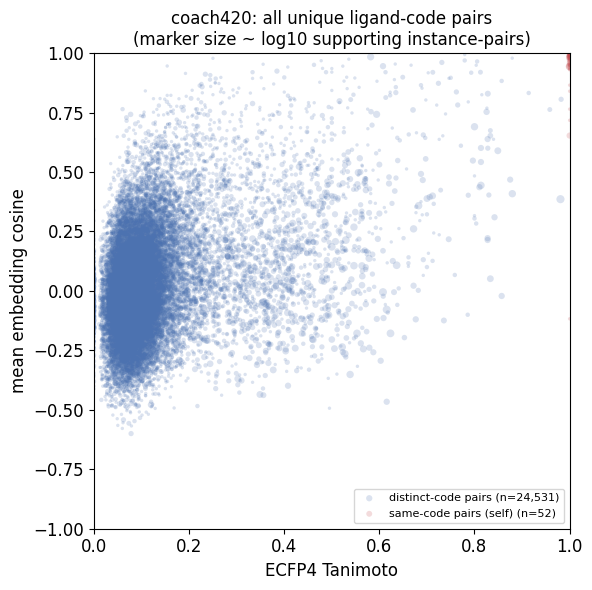

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_scpdb_unique_pairs_sem.png


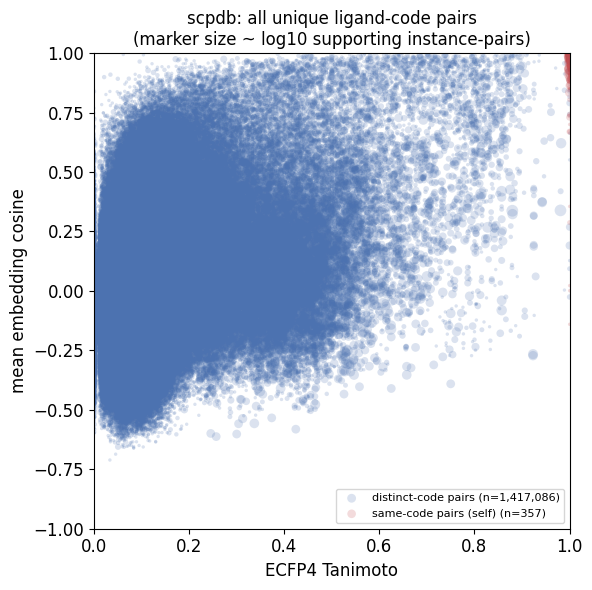

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_pdbbind2020_unique_pairs_sem.png


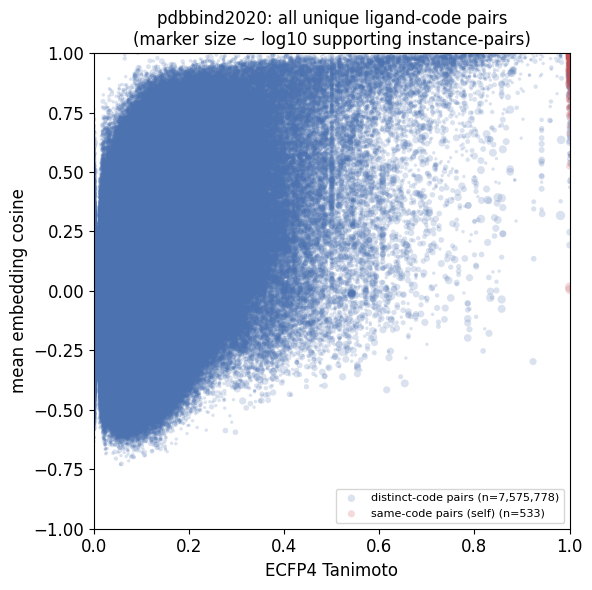

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_holo4k_unique_pairs_sem.png


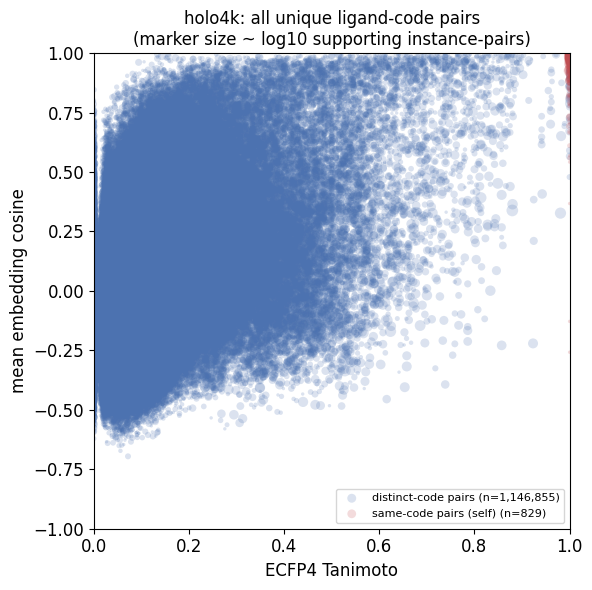

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_pooled_unique_pairs_sem.png


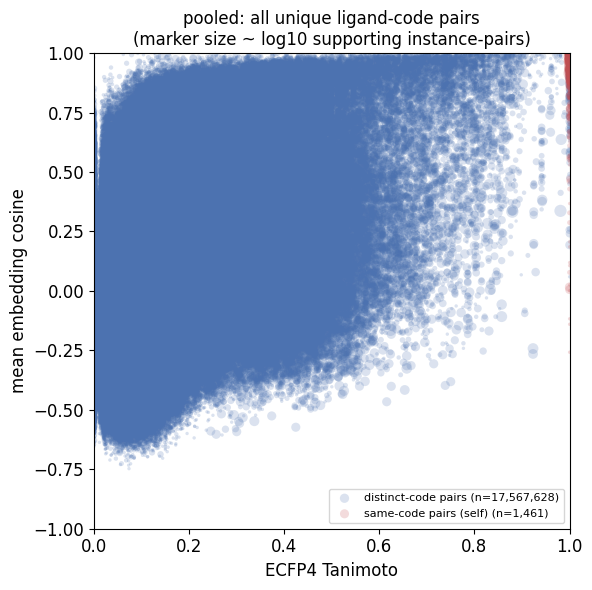

In [69]:
def plot_scope_sem(scope):
    tab = pair_tables[scope]
    self_w = tab[tab['is_self']]
    dist_w = tab[~tab['is_self']]
    fig, ax = plt.subplots(figsize=(7, 6))
    for sub, color, label in [(dist_w, '#4c72b0', 'distinct-code pairs'),
                              (self_w, '#c44e52', 'same-code pairs (self)')]:
        if len(sub) == 0:
            continue
        sizes = 6 + 14 * np.log10(sub['n_instance_pairs'])
        ax.scatter(sub['tanimoto'], sub['mean_cos'], s=sizes, color=color,
                  alpha=0.2, edgecolors='none',
                  label=f'{label} (n={len(sub):,})', rasterized=True)
    ax.set_xlabel('ECFP4 Tanimoto', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('mean embedding cosine', fontsize=LABEL_FONTSIZE)
    ax.set_xlim(0, 1); ax.set_ylim(-1, 1)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.set_title(f'{scope}: all unique ligand-code pairs\n'
                f'(marker size ~ log10 supporting instance-pairs)',
                fontsize=TITLE_FONTSIZE)
    ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()
    out = OUT_DIR / f'fig_{scope}_unique_pairs_sem.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print('wrote', out)
    plt.show()

for scope in SCOPES:
    plot_scope_sem(scope)

## Binned median + IQR trend (distinct-code pairs only)

The scatter above is honest but, at the pooled scale, mostly just a
dense cloud. Binning by Tanimoto and tracking the **median** mean
cosine per bin (+/- IQR) turns the same data into a single readable
trend line - the standard 'de-noise a huge scatter' move, and cheap
regardless of scope size since it aggregates over ~40 bins, not per
point. Self-comparisons are dropped entirely here (not just from the
trend line - the background scatter too), since every self pair sits
at Tanimoto = 1 by construction and adds nothing but a wall of points
at the right edge.

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_pooled_unique_pairs_trend.png


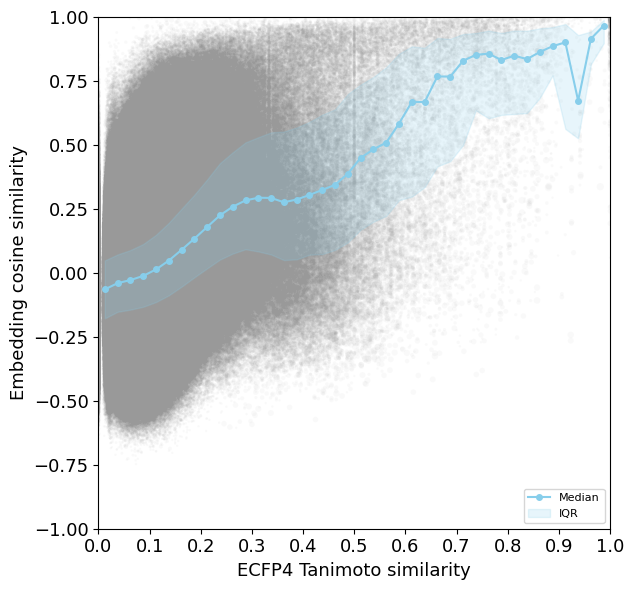

In [77]:
def plot_scope_trend(scope, n_bins=40):
    tab = pair_tables[scope]
    dist = tab[~tab['is_self']]

    edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(dist['tanimoto'], edges) - 1, 0, n_bins - 1)
    stats = dist['mean_cos'].groupby(bin_idx).agg(
        median='median', q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75), n='size')
    stats = stats.reindex(range(n_bins))
    centers = (edges[:-1] + edges[1:]) / 2

    sizes = 3 + 5 * np.log10(dist['n_instance_pairs'])

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(dist['tanimoto'], dist['mean_cos'], s=sizes, color='0.6',
              alpha=0.05, edgecolors='none', rasterized=True, zorder=1)
    ax.plot(centers, stats['median'], color='skyblue', marker='o', ms=4,
           label='Median', zorder=3)
    ax.fill_between(centers, stats['q25'], stats['q75'], color='skyblue',
                    alpha=0.2, label='IQR', zorder=2)
    ax.set_xlabel('ECFP4 Tanimoto similarity', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Embedding cosine similarity', fontsize=LABEL_FONTSIZE)
    ax.set_xlim(0, 1); ax.set_ylim(-1, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()
    out = OUT_DIR / f'fig_{scope}_unique_pairs_trend.png'
    fig.savefig(out, dpi=600, bbox_inches='tight')
    print('wrote', out)
    plt.show()

#for scope in SCOPES:
    #plot_scope_trend(scope)
plot_scope_trend("pooled") 

In [57]:
SCOPES.keys()

dict_keys(['coach420', 'scpdb', 'pdbbind2020', 'holo4k', 'pooled'])

## Per-ligand embedding consistency (same ligand, different structures)

A different question: for a *single* ligand code, how consistent is
its embedding across the different structures it is bound in? This
uses the pooled, cross-dataset-deduplicated corpus built above
(`codes_pooled` / `emb_pooled` - the same PDB bound to the same
ligand in more than one dataset is already collapsed to one
representative). Self-comparisons (an instance against itself) are
never included - every pair below is two *different* structures
that happen to share a ligand code, from `np.triu_indices(k, 1)`.

Each qualifying ligand code (>= 2 structures) gets its own small
instance x instance block, so this is computed directly and exactly
- no sampling, no closed-form shortcuts needed at this scale.

In [9]:
from collections import defaultdict

avgE_pooled = unit_rows(emb_pooled.mean(axis=1))

by_code = defaultdict(list)
for i, c in enumerate(codes_pooled):
    by_code[c].append(i)

lig_rows = []
pair_cos_by_code = {}
for c, idxs in by_code.items():
    k = len(idxs)
    if k < 2:
        continue
    idxs = np.array(idxs)
    sub = avgE_pooled[idxs]
    iu = np.triu_indices(k, 1)
    cosv = (sub @ sub.T)[iu].astype(np.float32)
    pair_cos_by_code[c] = cosv
    lig_rows.append({'code': c, 'n_conformers': k,
                     'n_comparisons': int(cosv.size),
                     'mean_cos': float(cosv.mean()),
                     'sem_cos': (float(cosv.std(ddof=1) / np.sqrt(cosv.size))
                                if cosv.size > 1 else np.nan)})

lig_summary = pd.DataFrame(lig_rows).sort_values(
    'n_conformers', ascending=False).reset_index(drop=True)
lig_summary.to_csv(OUT_DIR / 'per_ligand_cosine.tsv', sep='\t', index=False)

print(f'total unique ligand codes (pooled, deduped): {len(set(codes_pooled)):,}')
print(f'ligands with >=2 structures (can form a same-ligand comparison): '
     f'{len(lig_summary):,}')
print(f'total same-ligand comparisons: {int(lig_summary["n_comparisons"].sum()):,}')
print()
print('top 10 by structure count:')
print(lig_summary.head(10)[['code', 'n_conformers', 'n_comparisons', 'mean_cos',
                            'sem_cos']].to_string(index=False))

total unique ligand codes (pooled, deduped): 5,928
ligands with >=2 structures (can form a same-ligand comparison): 1,461
total same-ligand comparisons: 716,413

top 10 by structure count:
code  n_conformers  n_comparisons  mean_cos  sem_cos
 NAD           604         182106  0.914230 0.000560
 FAD           548         149878  0.986447 0.000099
 ADP           463         106953  0.969526 0.000319
 FMN           320          51040  0.985037 0.000255
 NAP           263          34453  0.924383 0.000819
 ATP           261          33930  0.965255 0.000636
 SAH           219          23871  0.973506 0.000722
 NDP           196          19110  0.942431 0.000907
 GDP           189          17766  0.971818 0.000450
 ANP           176          15400  0.947774 0.001225


In [10]:
lig_summary.mean_cos.mean()

0.9585151769919081

rest: 1,446 ligands, 50,650 comparisons, mean=0.9403, sem=0.00081
wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_per_ligand_cosine_top10.png


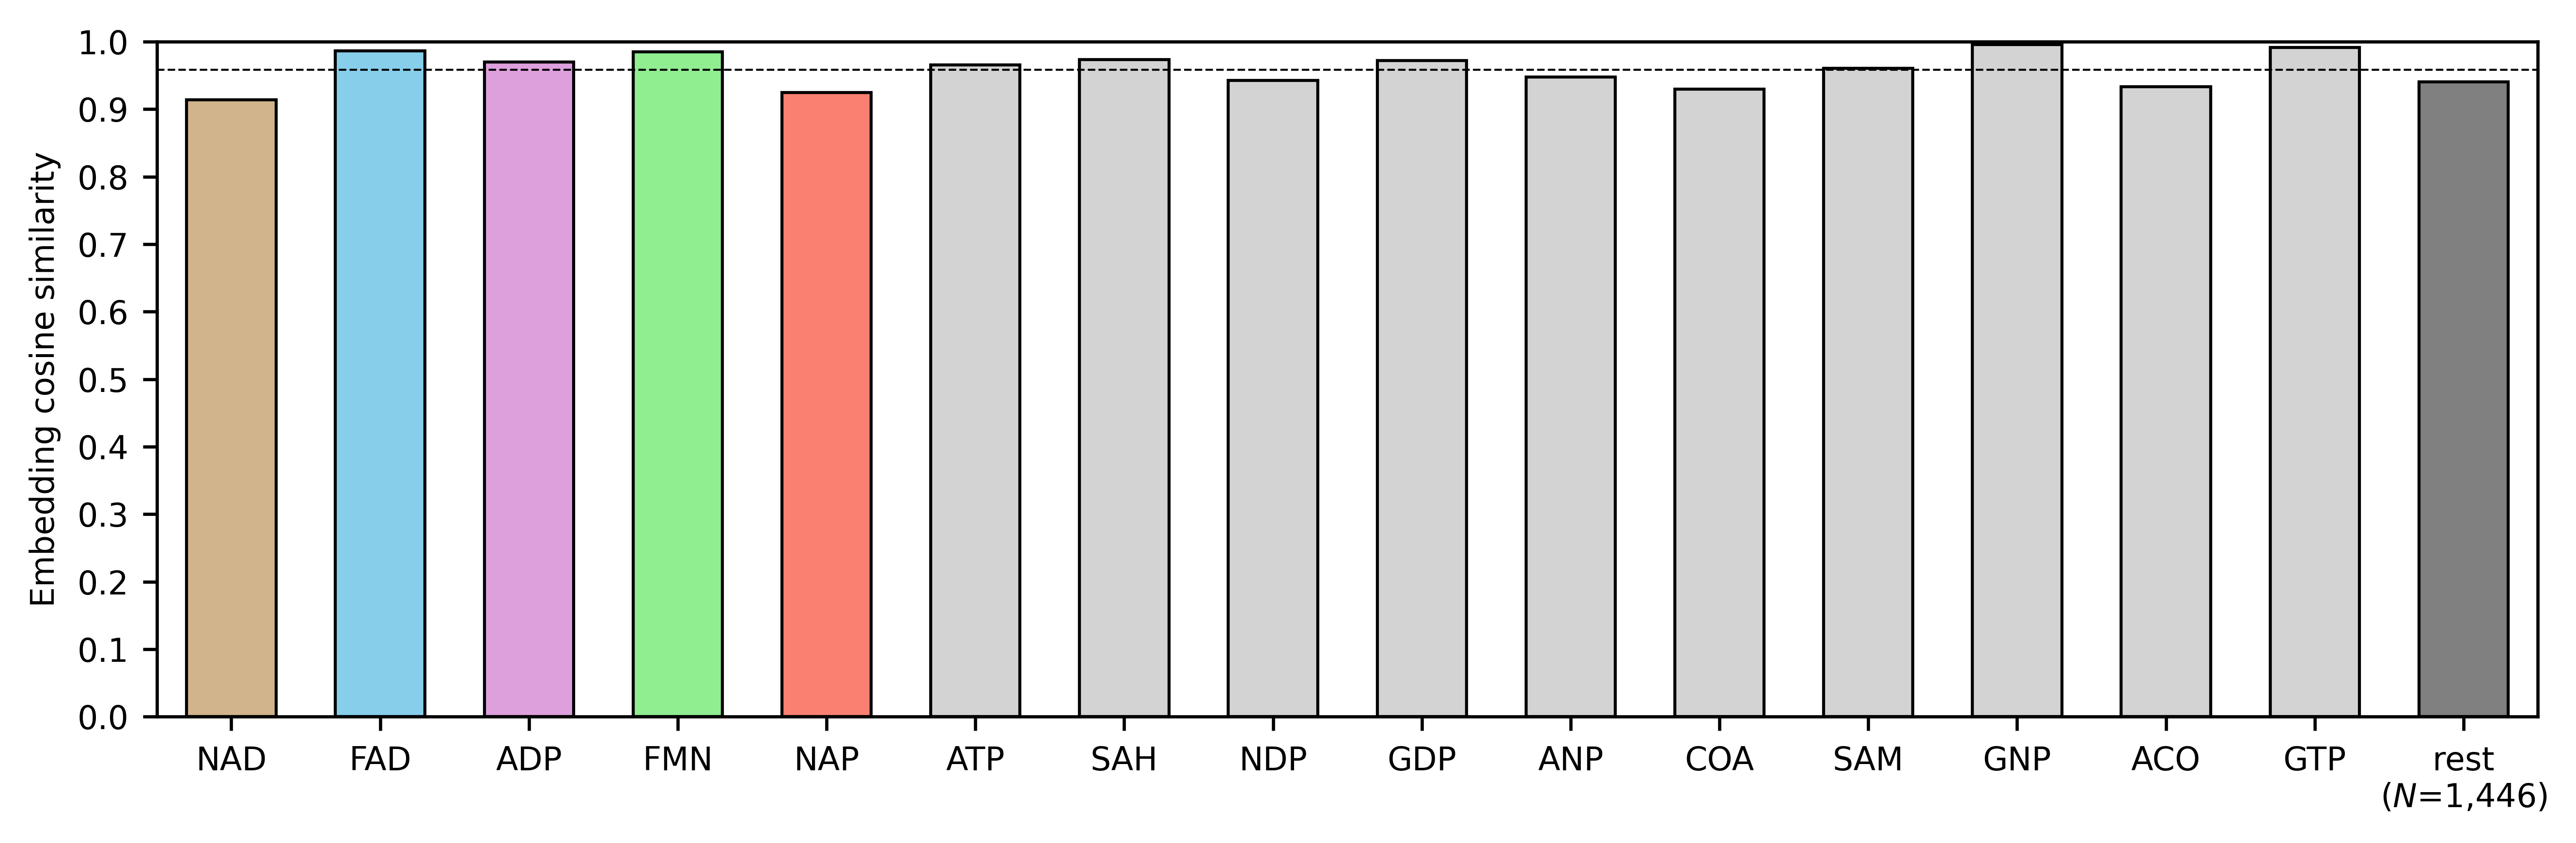

In [75]:
TOP_N = 15
top = lig_summary.head(TOP_N)
rest = lig_summary.iloc[TOP_N:]
rest_vals = np.concatenate([pair_cos_by_code[c] for c in rest['code']])
rest_mean = float(rest_vals.mean())
rest_sem = float(rest_vals.std(ddof=1) / np.sqrt(rest_vals.size))
print(f'rest: {len(rest):,} ligands, {rest_vals.size:,} comparisons, '
     f'mean={rest_mean:.4f}, sem={rest_sem:.5f}')

labels = list(top['code']) + [f'rest\n($N$={len(rest):,})']
means = list(top['mean_cos']) + [rest_mean]
sems = list(top['sem_cos']) + [rest_sem]
highlight_colors = ['tan', 'skyblue', 'plum', 'lightgreen', 'salmon']
colors = (highlight_colors + ['lightgrey'] * (TOP_N - len(highlight_colors))
         + ['grey'])

fig, ax = plt.subplots(figsize=(9, 3), dpi = 600)
x = np.arange(len(labels))
ax.bar(x, means, color=colors, edgecolor='black', linewidth=0.75, capsize=3, width=0.6) #yerr=sems,
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0, ha='center',
                                    fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_ylabel('Embedding cosine similarity', fontsize=8)
ax.set_ylim(0, 1)
ax.set_xlim(-0.5, 15.5)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.axhline(y=0.9585, ls = "--", lw = 0.5, c = "k")
#ax.set_title('Per-ligand embedding consistency across structures\n'
            #'(pooled, cross-dataset duplicates dropped, self-comparisons excluded)',
            #fontsize=TITLE_FONTSIZE)
fig.tight_layout()
out = OUT_DIR / 'fig_per_ligand_cosine_top10.png'
fig.savefig(out, dpi=600, bbox_inches='tight')
print('wrote', out)
plt.show()

## Raw, frequency-weighted baseline (for comparison)

Recomputes the original notebook-18-style sampled *instance*-pair
correlation, per scope (the four datasets, plus the pooled/deduped
corpus treated as a fifth scope), so the deduplicated unique-pair
correlations above can be compared directly against the frequency-
weighted numbers they are meant to replace.

In [12]:
raw_results = []
rng = np.random.default_rng(SEED)
for scope, s in SCOPES.items():
    n = len(s['codes'])
    ii, jj = sample_pairs(n, MAX_PAIRS, rng)
    tan = tanimoto_pairs(s['fps'], ii, jj)
    for mode in MODES:
        E = mode_embedding(s['emb'], mode)
        cos = cosine_pairs(E, ii, jj)
        r = pearsonr(tan, cos).statistic
        rho = spearmanr(tan, cos).statistic
        distinct = tan < 0.999
        if distinct.sum() > 10:
            r_d = pearsonr(tan[distinct], cos[distinct]).statistic
            rho_d = spearmanr(tan[distinct], cos[distinct]).statistic
        else:
            r_d = rho_d = np.nan
        raw_results.append({'scope': scope, 'mode': mode, 'n_pairs': len(ii),
                            'pearson': r, 'spearman': rho,
                            'pearson_distinct': r_d,
                            'spearman_distinct': rho_d})
    print(f'{scope:12s} raw pairs={len(ii):,}')

res_raw = pd.DataFrame(raw_results)
res_raw.to_csv(OUT_DIR / 'raw_pair_correlations.tsv', sep='\t', index=False)
print('\nwrote', OUT_DIR / 'raw_pair_correlations.tsv')

coach420     raw pairs=54,285


scpdb        raw pairs=1,000,000


pdbbind2020  raw pairs=1,000,000


holo4k       raw pairs=1,000,000


pooled       raw pairs=1,000,000

wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/raw_pair_correlations.tsv


## Weighted (raw) vs unweighted (unique-pair) comparison

Spearman rho for the average embedding, side by side: raw sampled
instance pairs (frequency-weighted - common cofactors dominate) vs
deduplicated unique ligand-code pairs (unweighted - every ligand
combination counts once), each split into all-pairs and
distinct-code-only.

             raw_all  raw_distinct  unique_all  unique_distinct
scope                                                          
coach420       0.278         0.267       0.292            0.288
scpdb          0.253         0.212       0.226            0.226
pdbbind2020    0.229         0.228       0.235            0.235
holo4k         0.250         0.228       0.272            0.270
pooled         0.209         0.194       0.228            0.228
wrote /Users/jsutges/Documents/NATURAL_LIGANDS/RESULTS/embedding_vs_tanimoto_unique_pairs/fig_weighted_vs_unweighted.png


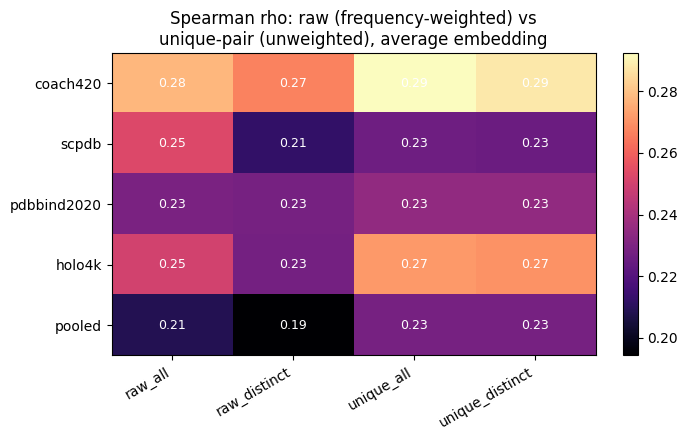

In [66]:
avg_unique = res_unique[res_unique['mode'] == 'average'].set_index('scope')
avg_raw = res_raw[res_raw['mode'] == 'average'].set_index('scope')
comparison = pd.DataFrame({
    'raw_all': avg_raw['spearman'],
    'raw_distinct': avg_raw['spearman_distinct'],
    'unique_all': avg_unique['spearman'],
    'unique_distinct': avg_unique['spearman_distinct'],
}).reindex(list(SCOPES))
print(comparison.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(comparison.values, aspect='auto', cmap='magma',
               vmin=np.nanmin(comparison.values),
               vmax=np.nanmax(comparison.values))
ax.set_xticks(range(len(comparison.columns)))
ax.set_xticklabels(comparison.columns, rotation=30, ha='right',
                   fontsize=TICK_FONTSIZE)
ax.set_yticks(range(len(comparison.index)))
ax.set_yticklabels(comparison.index, fontsize=TICK_FONTSIZE)
for yi in range(comparison.shape[0]):
    for xi in range(comparison.shape[1]):
        v = comparison.values[yi, xi]
        if np.isfinite(v):
            ax.text(xi, yi, f'{v:.2f}', ha='center', va='center',
                   color='w', fontsize=9)
ax.set_title('Spearman rho: raw (frequency-weighted) vs\n'
            'unique-pair (unweighted), average embedding', fontsize=TITLE_FONTSIZE)
plt.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
out = OUT_DIR / 'fig_weighted_vs_unweighted.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('wrote', out)
plt.show()

## Takeaways

- **Cross-dataset dedup matters for the pooled scope.** Some PDB
  structures are independently curated into more than one of the
  four datasets; without collapsing `(pdb_id, lig_resname)` to one
  representative first, pooling would double- (or triple-) count
  those poses.
- **Tanimoto only needs computing once per unique ligand-code pair.**
  It does not depend on how many structures happen to bind that
  ligand, so there is no reason to recompute (or resample) it per
  instance pair - the exact pairwise Tanimoto matrix over unique
  codes is cheap even at thousands of codes.
- **Mean cosine per unique pair is computed exactly, not sampled.**
  The full instance-level cosine matrix (`E @ E.T`) is one matrix
  multiply even for the pooled ~17k-molecule corpus, so grouping by
  unique ligand-code pair to get an exact mean + SEM needs no random
  sampling anywhere in this notebook.
- Compare the `unique_*` columns against the `raw_*` columns in the
  weighted-vs-unweighted heatmap above: if they move together, the
  cosine-Tanimoto relationship in notebook 18 was not just an
  artefact of a few overrepresented cofactors. If they diverge, the
  frequency-weighted numbers were being pulled around by how often
  particular ligands happen to occur, rather than by how broadly the
  correlation actually holds across distinct ligand pairs.